# File Starts here

In [17]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

from circuit_extract import visualize_circuit_masks
from utils import *
import circuit_extract as ce
import inference
import train

In [18]:
os.makedirs("out", exist_ok=True)

In [19]:
import importlib

importlib.reload(inference)
importlib.reload(train)
importlib.reload(ce)

<module 'circuit_extract' from '/home/cabbagepatch/Code/MI/vast/Mechanistic-Interpretability/circuit_extract.py'>

In [20]:
def model_config(ds_name: str, lr: float, epochs: int, seed: int=0):
    return {
        "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        "seed": seed,
        "dataset": ds_name,
        "epochs": epochs, 
        "lr": lr,
    }

def circuit_config(ds_name: str, lr: float, cepochs: int, k_w: int, seed: int=0):
    return {
        "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        "seed": seed,
        "dataset": ds_name,
        "cepochs": cepochs, 
        "lr": lr,
        "k_w": k_w,
    }

### Train Sparse Model ###

In [21]:
print("\n--- Phase 1: Initialize Model ---")
inp_shape = (1, 28, 28)
model = inference.CNN(nc=1, nf=16, num_classes=10, inp_shape=inp_shape)


--- Phase 1: Initialize Model ---


In [22]:
print("\n--- Phase 2: Train Sparse Baseline ---")
sched = scheduler(start = 2, end= 10, start_sparsity=1, target_sparsity=0.10, alpha=0.15)

# for i in range(55):
#     print(sched(i))

epochs = 15


cfg = model_config(ds_name='mnist', lr=1e-3, epochs=epochs)
device = cfg['device']
print(f"Running on {device}")



train.train_model(
    model=model,
    lr=cfg['lr'],
    b1=0.9, b2=0.999,
    scheduler = sched, 
    ds_name="mnist-baseline",
    eps=1e-8,
    epochs=cfg['epochs'],
    device=device,
    seed=cfg['seed']
)


--- Phase 2: Train Sparse Baseline ---
Running on cpu
n_params 20432 n_params_wd 20432
cpu


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 0 | Train Acc: 0.9782 | Test Acc: 0.9797
Epoch 1 | Train Acc: 0.9853 | Test Acc: 0.9851
Epoch 2 | Train Acc: 0.9349 | Test Acc: 0.9397
Epoch 3 | Train Acc: 0.9389 | Test Acc: 0.9444
Epoch 4 | Train Acc: 0.9440 | Test Acc: 0.9479
Epoch 5 | Train Acc: 0.9513 | Test Acc: 0.9549
Epoch 6 | Train Acc: 0.9568 | Test Acc: 0.9581
Epoch 7 | Train Acc: 0.9586 | Test Acc: 0.9614
Epoch 8 | Train Acc: 0.9622 | Test Acc: 0.9648
Epoch 9 | Train Acc: 0.9618 | Test Acc: 0.9613
Epoch 10 | Train Acc: 0.9636 | Test Acc: 0.9628
Epoch 11 | Train Acc: 0.9640 | Test Acc: 0.9645
Epoch 12 | Train Acc: 0.9659 | Test Acc: 0.9654
Epoch 13 | Train Acc: 0.9570 | Test Acc: 0.9565
Epoch 14 | Train Acc: 0.9678 | Test Acc: 0.9679


In [23]:
print(f'CUDA available: {torch.cuda.is_available()}') 
print(f'Device count: {torch.cuda.device_count()}')
print(f'Current device: {torch.cuda.current_device() if torch.cuda.is_available() else None}')


CUDA available: False
Device count: 0
Current device: None


In [24]:
non_zero = sum([(p != 0).sum() for p in model.parameters()])
total = sum([p.numel() for p in model.parameters()])

print(f"{non_zero/total:.4f}")

0.0999


In [24]:
# when retaining also retain other ones
# scheduler also add (50 percent of training steos then reach sparsity)
# iteratively sparsify features after starting from 0 percent sparsty
# circuits should not rely on 
# for every neuron retain some weights
# try pretraining on generation
#try on more complex datasets, cmnist, cifar10, pacs
#maybe try portability
#try training on
#try the weird loss thing
#mistake : apply sigmoid estimator
#see this as an angle to improve DG
#how to work with circuits that are not end to end // have to use bigger models
#ha405 // visual reasoning
#how to find neurons/circuits correspoding to sprurious features / circuits
#work with different circuits in cross-domain settings
#randomization makes network more generalizable
#maybe try and find work in compilers?
#LLMs ka kaam karo
#senior

# New

### get 1 circuit from each class from same trained model

In [25]:
trainloader, testloader = train.load_dataset("mnist-baseline")

Extracting circuit for class 0
 Processing Class 0 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-0


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.4069 | Avg Mask: -0.963 | Total Non-Zero: 315.0 | | Circuit Acc: 0.9737

--- Visualizing Circuit for Class 0 ---


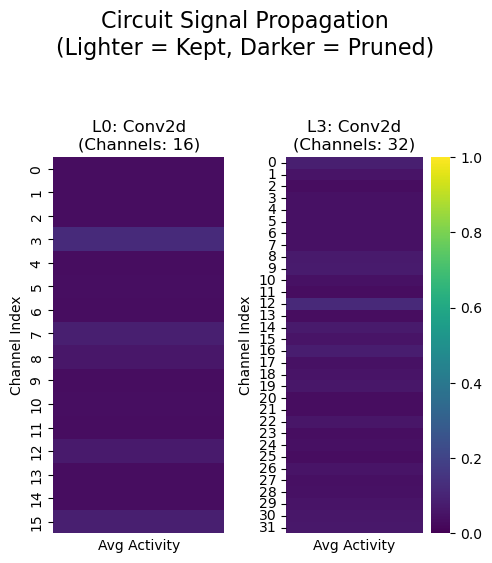


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_0.png
Extracting circuit for class 1
 Processing Class 1 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-1


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
 

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 11.6931 | Avg Mask: -0.935 | Total Non-Zero: 493.0 | | Circuit Acc: 0.9743

--- Visualizing Circuit for Class 1 ---


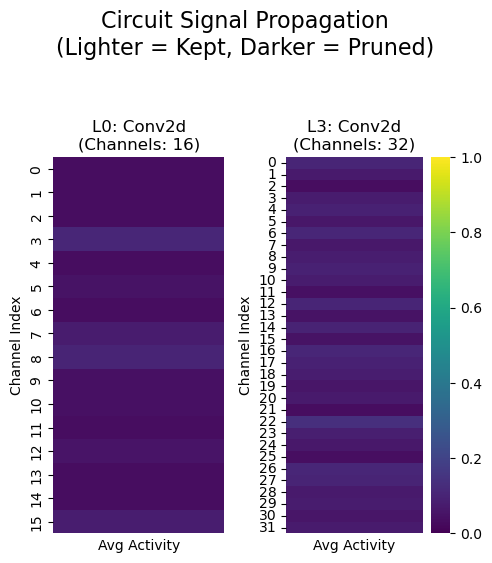


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_1.png
Extracting circuit for class 2
 Processing Class 2 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-2


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
 

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.5845 | Avg Mask: -0.967 | Total Non-Zero: 290.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 2 ---


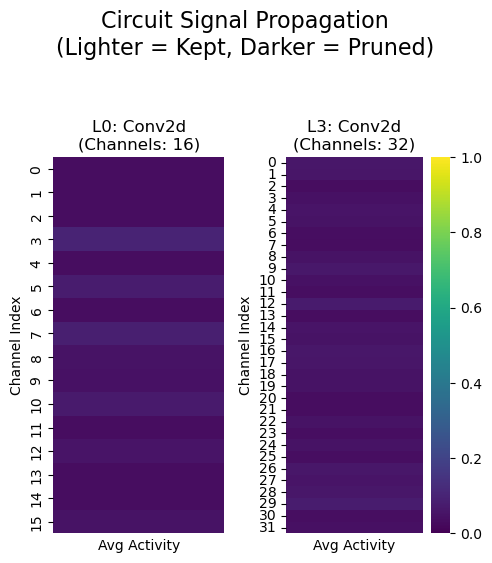


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_2.png
Extracting circuit for class 3
 Processing Class 3 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-3


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
 

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.5629 | Avg Mask: -0.965 | Total Non-Zero: 306.0 | | Circuit Acc: 0.9998

--- Visualizing Circuit for Class 3 ---


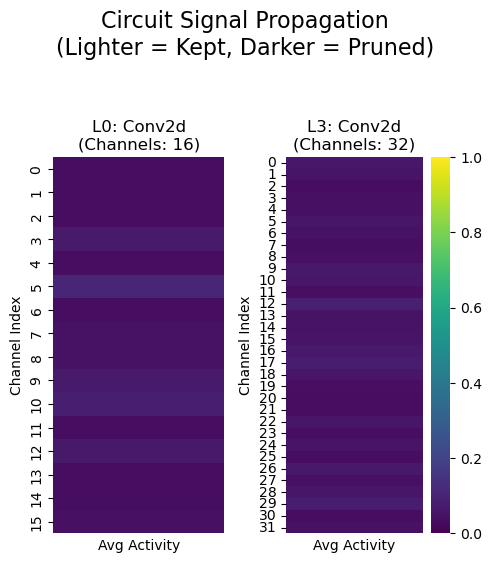


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_3.png
Extracting circuit for class 4
 Processing Class 4 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-4


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
 

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 13.0777 | Avg Mask: -0.949 | Total Non-Zero: 439.0 | | Circuit Acc: 0.9870

--- Visualizing Circuit for Class 4 ---


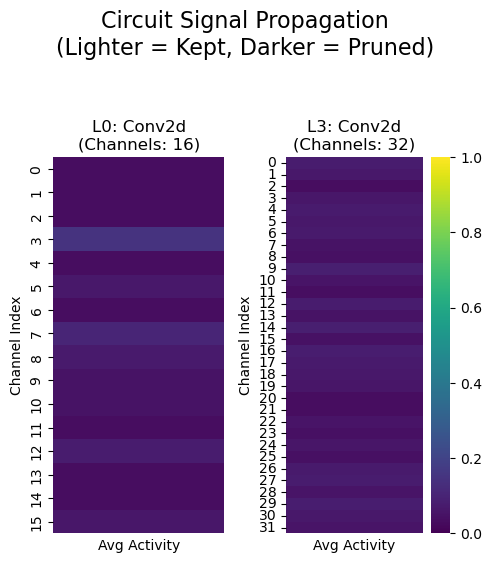


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_4.png
Extracting circuit for class 5
 Processing Class 5 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-5


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
 

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 14.0866 | Avg Mask: -0.941 | Total Non-Zero: 497.0 | | Circuit Acc: 0.9956

--- Visualizing Circuit for Class 5 ---


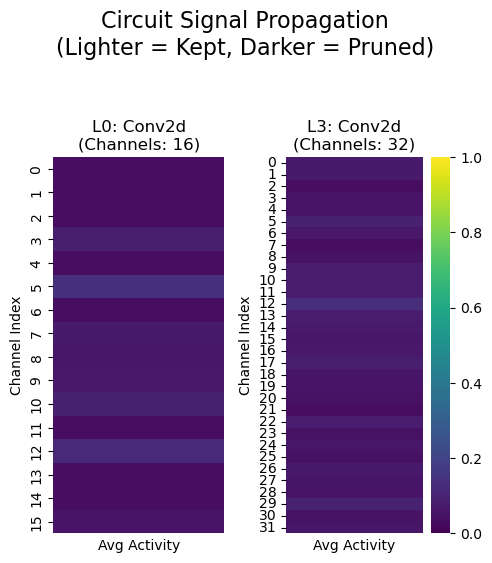


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_5.png
Extracting circuit for class 6
 Processing Class 6 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-6


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
 

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.4511 | Avg Mask: -0.958 | Total Non-Zero: 338.0 | | Circuit Acc: 0.9721

--- Visualizing Circuit for Class 6 ---


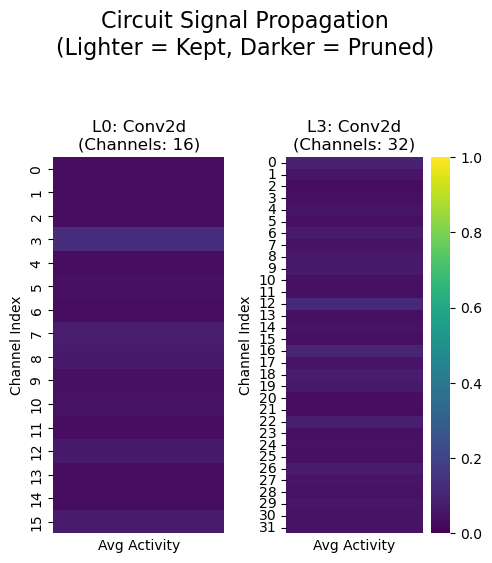


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_6.png
Extracting circuit for class 7
 Processing Class 7 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-7


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
 

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.1540 | Avg Mask: -0.955 | Total Non-Zero: 375.0 | | Circuit Acc: 0.9850

--- Visualizing Circuit for Class 7 ---


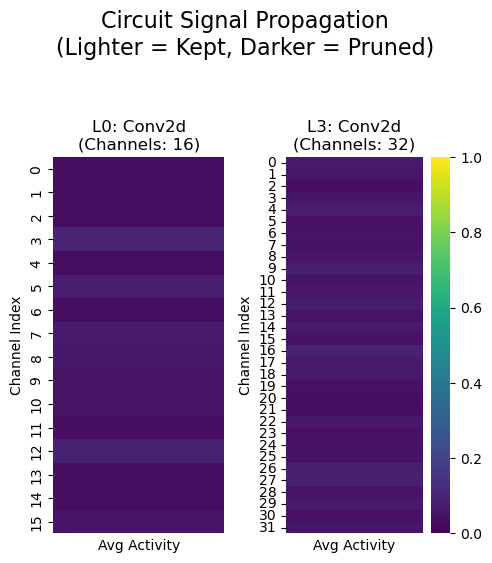


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_7.png
Extracting circuit for class 8
 Processing Class 8 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-8


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
 

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.9913 | Avg Mask: -0.965 | Total Non-Zero: 350.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


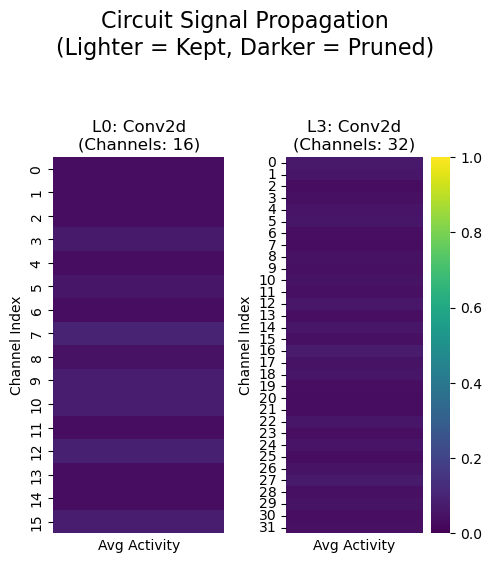


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting circuit for class 9
 Processing Class 9 
Configuration: Device=cpu, Lambda=50.0, Dataset=mnist-class-9


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
 

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.3801 | Avg Mask: -0.968 | Total Non-Zero: 279.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 9 ---


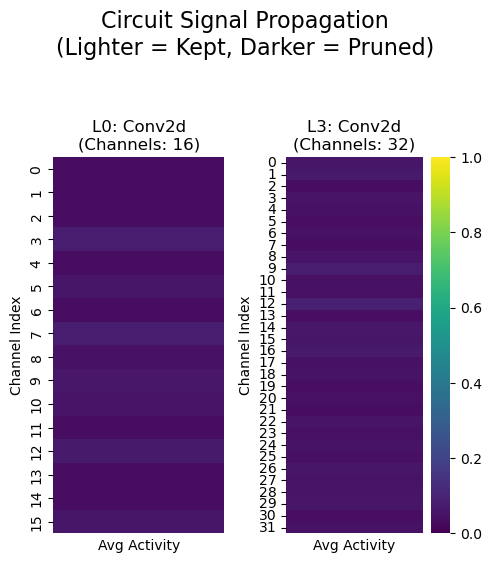


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_9.png


In [26]:
dict_10_classes = get_circuit_from_classes(
    model=model, 
    epochs=1,
    lr=0.1,
    l0_lambda=5e+1
)

In [ ]:
# MODEL_NAME =  "model"
# .save(model)

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


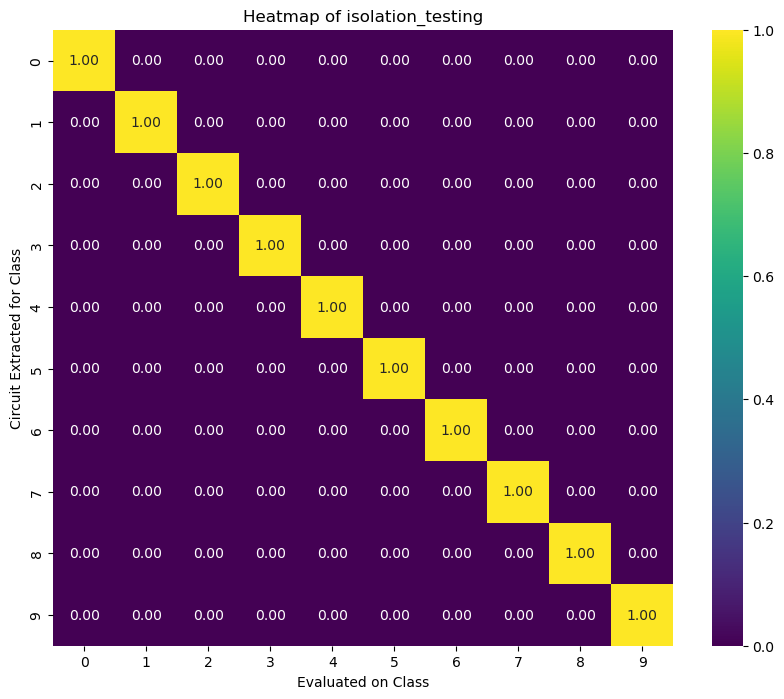

In [27]:
iso_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=dict_10_classes,
    test_func=isolation_testing,
    dataloader=trainloader,
    dev=device
)
plt.show()

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


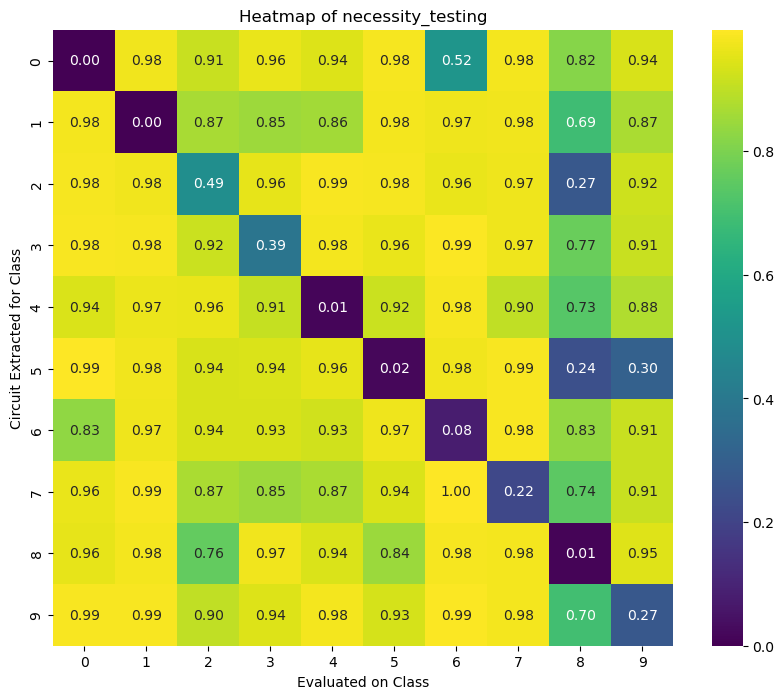

In [28]:
nec_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=dict_10_classes,
    test_func=necessity_testing,
    dataloader=trainloader,
    dev=device
)
# plt.savefig("out/nec_map.png", bbox_inches='tight')
plt.show()

In [14]:
for k,v in dict_10_classes.items():
    invert_masks(v)

In [15]:
dict_10_classes

{0: Circuit(
   (model): CNN(
     (encoder): Sequential(
       (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (1): ReLU()
       (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (4): ReLU()
       (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       (6): Flatten(start_dim=1, end_dim=-1)
     )
     (classifier): Sequential(
       (0): Linear(in_features=1568, out_features=10, bias=False)
     )
     (chain): ModuleList(
       (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (1): ReLU()
       (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (4): ReLU()
       (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [16]:
divergence_results = path_divergence_dict(
    circuits_dict=dict_10_classes,
    loader=trainloader,
    device=device
)

plot_path_divergence_trajectories(divergence_results, 'out/path_div_trajectory.png', title='Path Divergence')

UnboundLocalError: cannot access local variable 'batch_sims' where it is not associated with a value

In [63]:
sorted_pairs = sorted(divergence_results.items(), key=lambda x: x[1][-1], reverse=True)
    
for (c_a, c_b), layer_sims in sorted_pairs[:5]:
    formatted_sims = " | ".join([f"L{i}: {s:.3f}" for i, s in enumerate(layer_sims)])
    print(f"Classes ({c_a} vs {c_b}): {formatted_sims}")

Classes (4 vs 7): L0: 0.401 | L1: 0.412 | L2: 0.500 | L3: 0.239 | L4: 0.239 | L5: 0.234 | L6: 0.234 | L7: 0.577
Classes (4 vs 9): L0: 0.036 | L1: 0.033 | L2: 0.061 | L3: 0.120 | L4: 0.120 | L5: 0.179 | L6: 0.179 | L7: 0.547
Classes (2 vs 7): L0: 0.143 | L1: 0.153 | L2: 0.234 | L3: 0.072 | L4: 0.072 | L5: 0.110 | L6: 0.110 | L7: 0.455
Classes (7 vs 9): L0: 0.019 | L1: 0.017 | L2: 0.024 | L3: 0.052 | L4: 0.052 | L5: 0.142 | L6: 0.142 | L7: 0.449
Classes (8 vs 9): L0: 0.085 | L1: 0.080 | L2: 0.121 | L3: 0.073 | L4: 0.073 | L5: 0.121 | L6: 0.121 | L7: 0.420


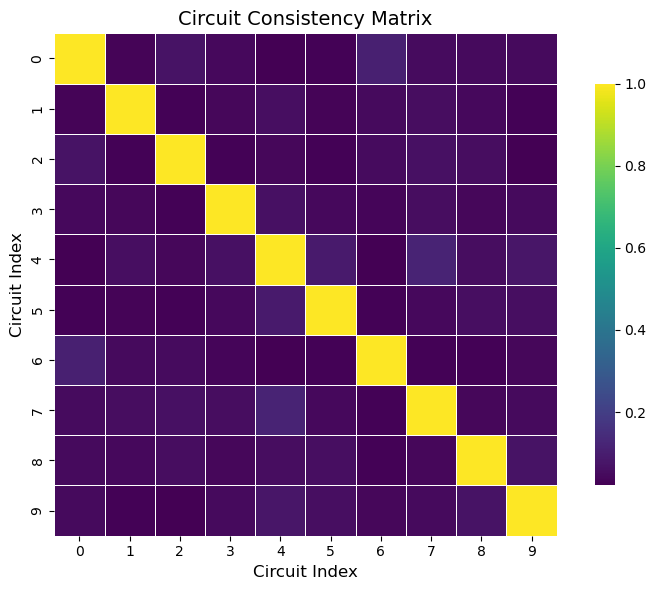

In [65]:
distinct_consistency_matrix = circuit_consistency_matrix(list(dict_10_classes.values()), len(dict_10_classes))

visualize_consistency_matrix(distinct_consistency_matrix)

In [ ]:
for target_class in [0, 5]:
    print(f"\nDeconstructing Circuit for Class {target_class}:")
    layerwise_circuits = get_layerwise_circuits(dict_10_classes[target_class])
    
    layer_accs = []
    for layer_idx, l_circ in layerwise_circuits.items():
        acc_dict = class_wise_acc(l_circ, testloader, classes=[target_class], device=device)
        acc = acc_dict[target_class]
        layer_accs.append(acc)
        print(f"Layer {layer_idx} Isolation Acc: {acc:.2%}")
        
    plt.figure(figsize=(8, 4))
    plt.plot(list(layerwise_circuits.keys()), layer_accs, marker='o')
    plt.title(f"Class {target_class}: Accuracy when ONLY Layer X is Pruned")
    plt.xlabel("Layer Index")
    plt.ylabel("Accuracy")
    plt.savefig(f"out/layerwise_class_{target_class}.png")
    plt.close()


Deconstructing Circuit for Class 0:


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Layer 0 Isolation Acc: 100.00%
Layer 3 Isolation Acc: 99.39%

Deconstructing Circuit for Class 5:
Layer 0 Isolation Acc: 99.78%
Layer 3 Isolation Acc: 91.37%



Interpolating between Class 3 and Class 8...
Alpha 0.0: Acc Class 3 = 20.30%, Acc Class 8 = 43.74%
Alpha 0.1: Acc Class 3 = 15.74%, Acc Class 8 = 43.02%
Alpha 0.2: Acc Class 3 = 15.54%, Acc Class 8 = 41.58%
Alpha 0.3: Acc Class 3 = 13.86%, Acc Class 8 = 33.37%
Alpha 0.4: Acc Class 3 = 22.28%, Acc Class 8 = 8.01%
Alpha 0.6: Acc Class 3 = 16.34%, Acc Class 8 = 47.23%
Alpha 0.7: Acc Class 3 = 35.45%, Acc Class 8 = 55.65%
Alpha 0.8: Acc Class 3 = 38.02%, Acc Class 8 = 57.60%
Alpha 0.9: Acc Class 3 = 36.44%, Acc Class 8 = 55.24%
Alpha 1.0: Acc Class 3 = 37.33%, Acc Class 8 = 54.11%


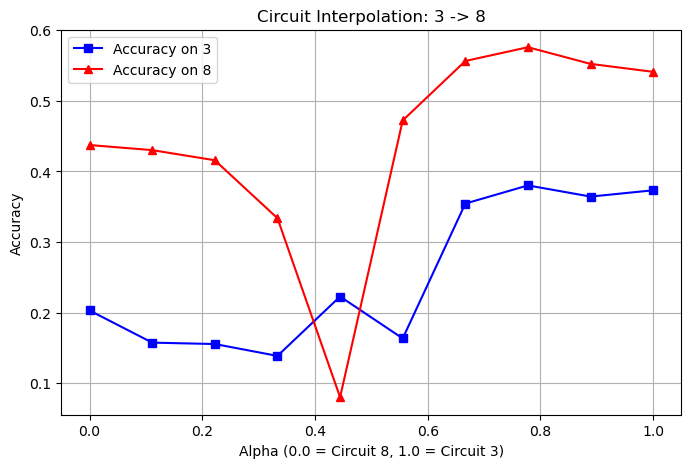


Interpolating between Class 4 and Class 9...
Alpha 0.0: Acc Class 4 = 0.00%, Acc Class 9 = 50.35%
Alpha 0.1: Acc Class 4 = 0.00%, Acc Class 9 = 41.23%
Alpha 0.2: Acc Class 4 = 0.00%, Acc Class 9 = 41.82%
Alpha 0.3: Acc Class 4 = 0.00%, Acc Class 9 = 27.75%
Alpha 0.4: Acc Class 4 = 0.00%, Acc Class 9 = 1.19%
Alpha 0.6: Acc Class 4 = 45.11%, Acc Class 9 = 0.00%
Alpha 0.7: Acc Class 4 = 61.91%, Acc Class 9 = 0.00%
Alpha 0.8: Acc Class 4 = 70.88%, Acc Class 9 = 0.00%
Alpha 0.9: Acc Class 4 = 73.22%, Acc Class 9 = 0.00%
Alpha 1.0: Acc Class 4 = 71.79%, Acc Class 9 = 0.00%


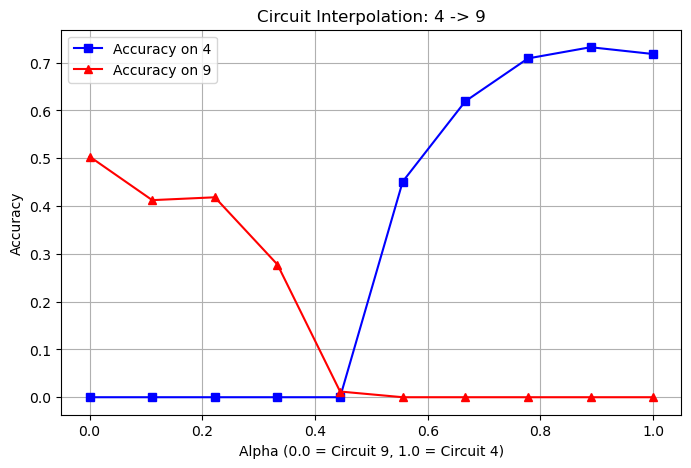


Interpolating between Class 1 and Class 7...
Alpha 0.0: Acc Class 1 = 0.00%, Acc Class 7 = 76.46%
Alpha 0.1: Acc Class 1 = 0.00%, Acc Class 7 = 76.36%
Alpha 0.2: Acc Class 1 = 0.00%, Acc Class 7 = 70.53%
Alpha 0.3: Acc Class 1 = 0.00%, Acc Class 7 = 67.90%
Alpha 0.4: Acc Class 1 = 0.00%, Acc Class 7 = 53.79%
Alpha 0.6: Acc Class 1 = 19.21%, Acc Class 7 = 0.00%
Alpha 0.7: Acc Class 1 = 35.07%, Acc Class 7 = 0.00%
Alpha 0.8: Acc Class 1 = 43.08%, Acc Class 7 = 0.00%
Alpha 0.9: Acc Class 1 = 49.52%, Acc Class 7 = 0.00%
Alpha 1.0: Acc Class 1 = 63.26%, Acc Class 7 = 0.00%


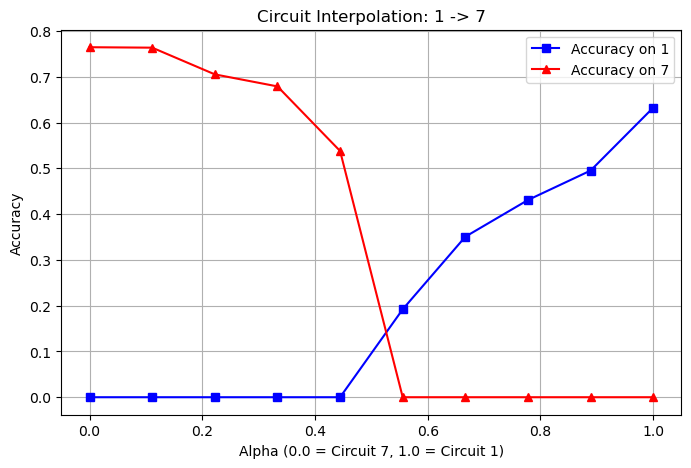


Interpolating between Class 6 and Class 9...
Alpha 0.0: Acc Class 6 = 0.31%, Acc Class 9 = 50.35%
Alpha 0.1: Acc Class 6 = 0.00%, Acc Class 9 = 41.33%
Alpha 0.2: Acc Class 6 = 0.21%, Acc Class 9 = 40.34%
Alpha 0.3: Acc Class 6 = 0.00%, Acc Class 9 = 25.67%
Alpha 0.4: Acc Class 6 = 0.00%, Acc Class 9 = 2.68%
Alpha 0.6: Acc Class 6 = 26.62%, Acc Class 9 = 0.00%
Alpha 0.7: Acc Class 6 = 56.26%, Acc Class 9 = 0.00%
Alpha 0.8: Acc Class 6 = 60.23%, Acc Class 9 = 0.00%
Alpha 0.9: Acc Class 6 = 60.75%, Acc Class 9 = 0.59%
Alpha 1.0: Acc Class 6 = 61.69%, Acc Class 9 = 0.50%


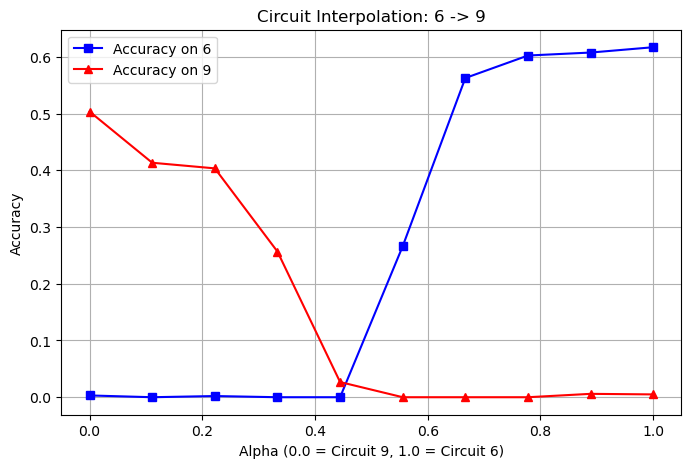

In [ ]:
pairs_to_interpolate = [(3, 8), (4, 9), (1, 7), (6, 9)]

for (class_a, class_b) in pairs_to_interpolate:
    print(f"\nInterpolating between Class {class_a} and Class {class_b}...")
    interp_circuits = get_interpolated_circuits(
        c_a=dict_10_classes[class_a], 
        c_b=dict_10_classes[class_b], 
        steps=10
    )
    
    acc_a_list, acc_b_list = [], []
    alphas = list(interp_circuits.keys())
    
    for alpha, interp_c in interp_circuits.items():
        accs = class_wise_acc(interp_c, testloader, classes=[class_a, class_b], device=device)
        acc_a_list.append(accs[class_a])
        acc_b_list.append(accs[class_b])
        print(f"Alpha {alpha:.1f}: Acc Class {class_a} = {accs[class_a]:.2%}, Acc Class {class_b} = {accs[class_b]:.2%}")
        
    plt.figure(figsize=(8, 5))
    plt.plot(alphas, acc_a_list, marker='s', label=f'Accuracy on {class_a}', color='blue')
    plt.plot(alphas, acc_b_list, marker='^', label=f'Accuracy on {class_b}', color='red')
    plt.title(f"Circuit Interpolation: {class_a} -> {class_b}")
    plt.xlabel(f"Alpha (0.0 = Circuit {class_b}, 1.0 = Circuit {class_a})")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
    # plt.savefig(f"out/interpolation_{class_a}_to_{class_b}.png")
    # plt.close()

### get n circuits same class same model

Extracting duplicate 1/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

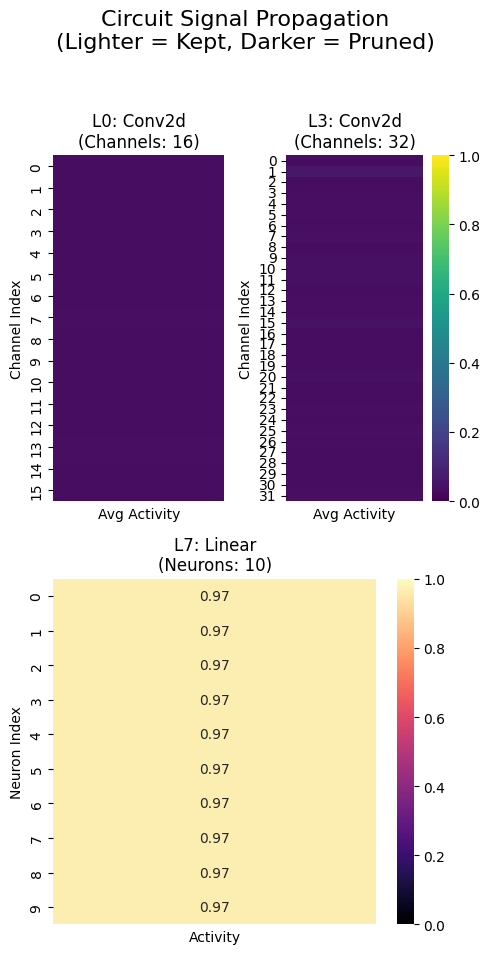


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png
Extracting duplicate 2/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

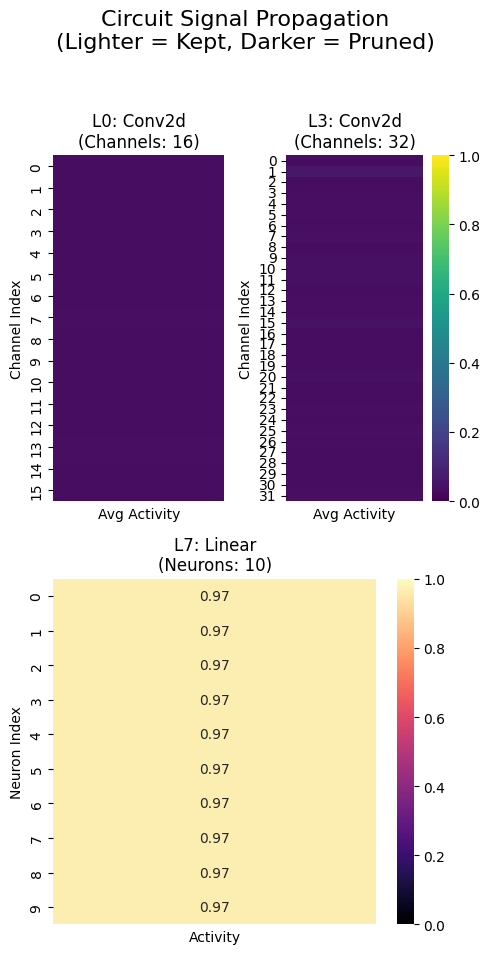


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png
Extracting duplicate 3/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

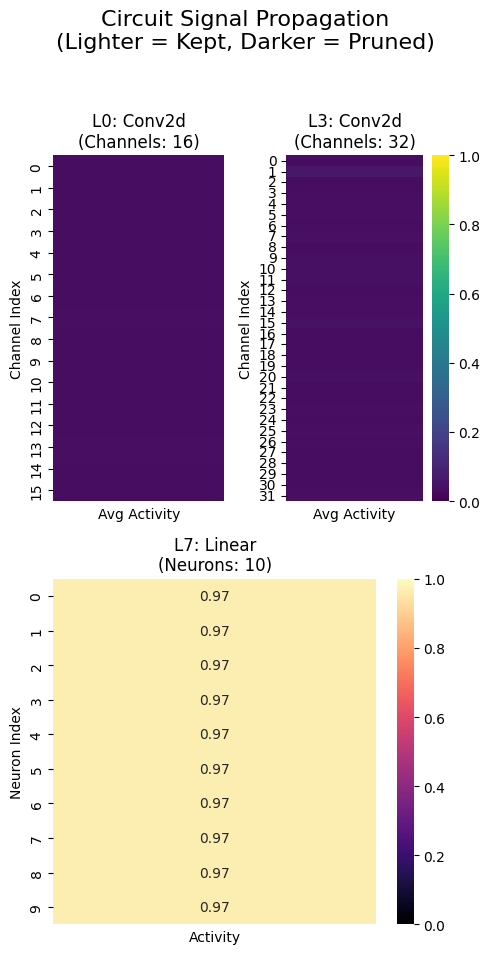


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png
Extracting duplicate 4/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

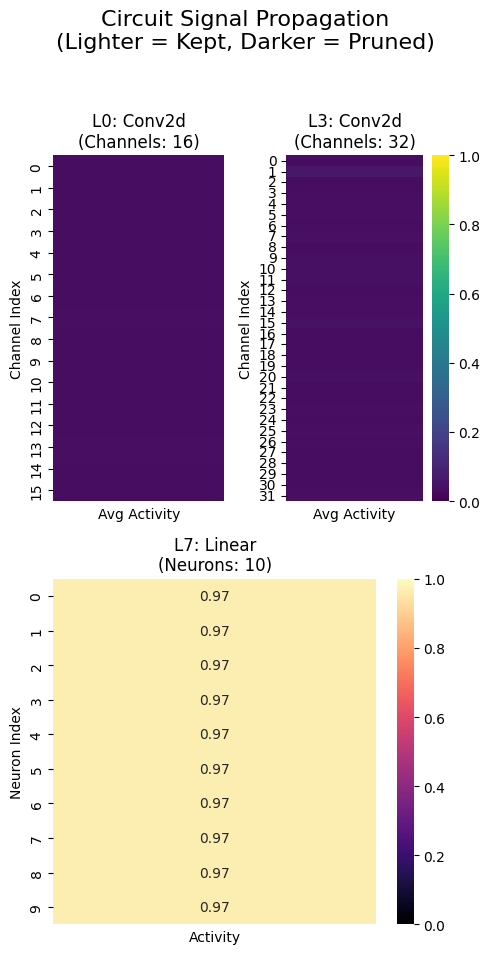


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png
Extracting duplicate 5/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

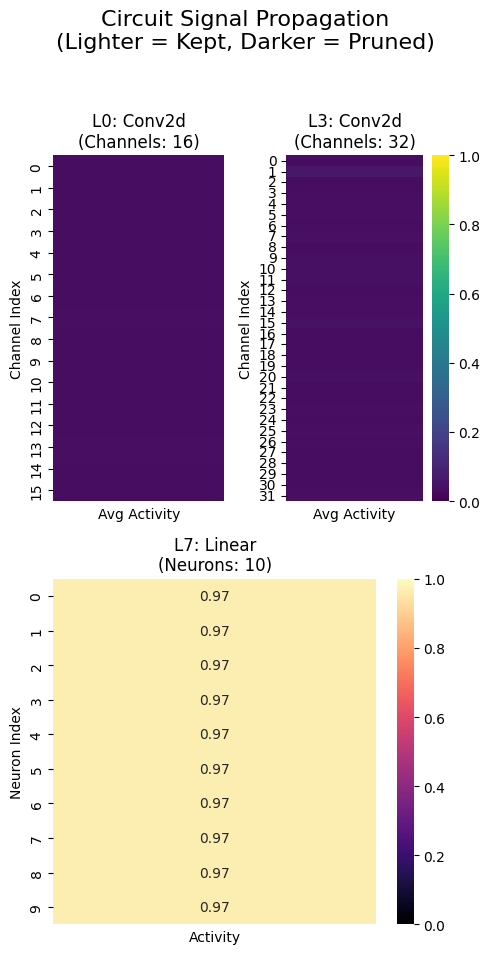


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png
Extracting duplicate 6/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

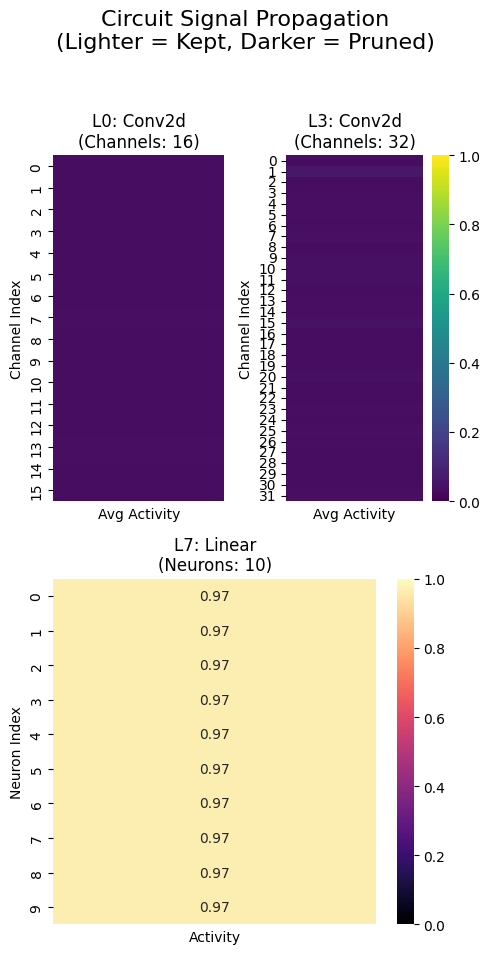


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png
Extracting duplicate 7/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

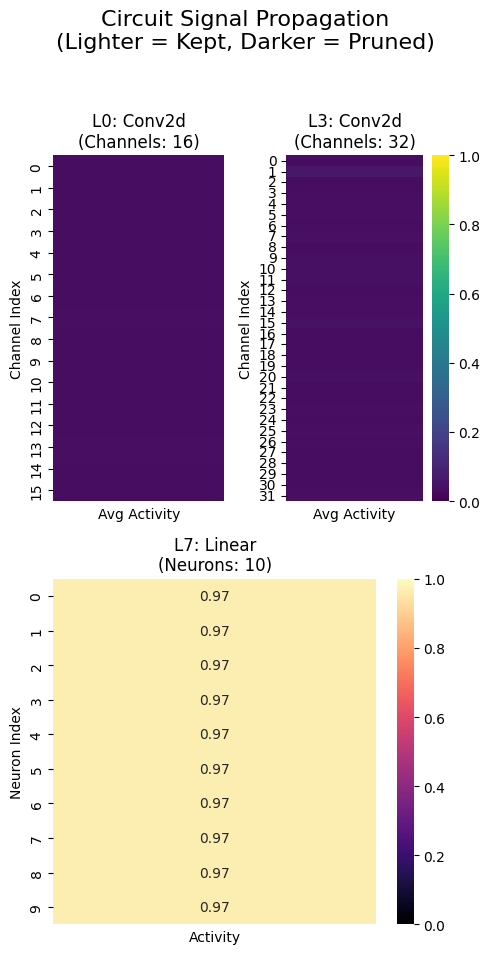


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png
Extracting duplicate 8/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

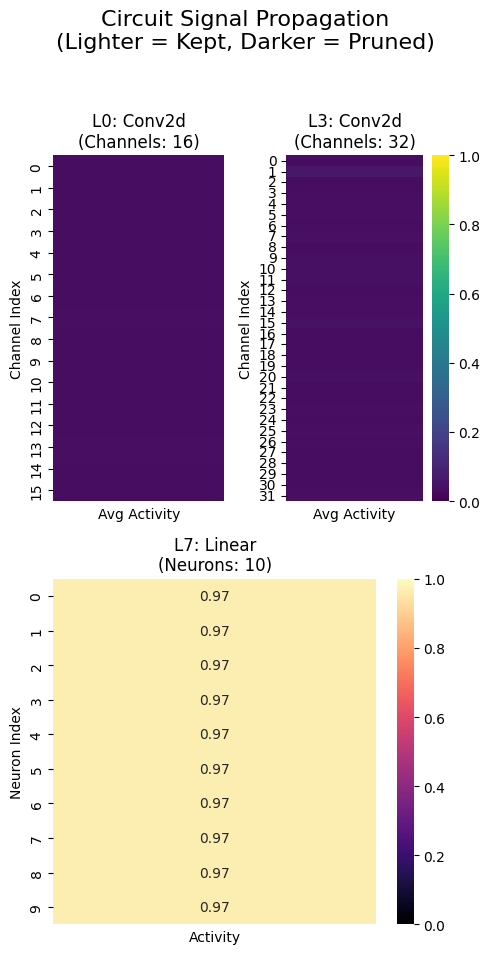


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png
Extracting duplicate 9/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

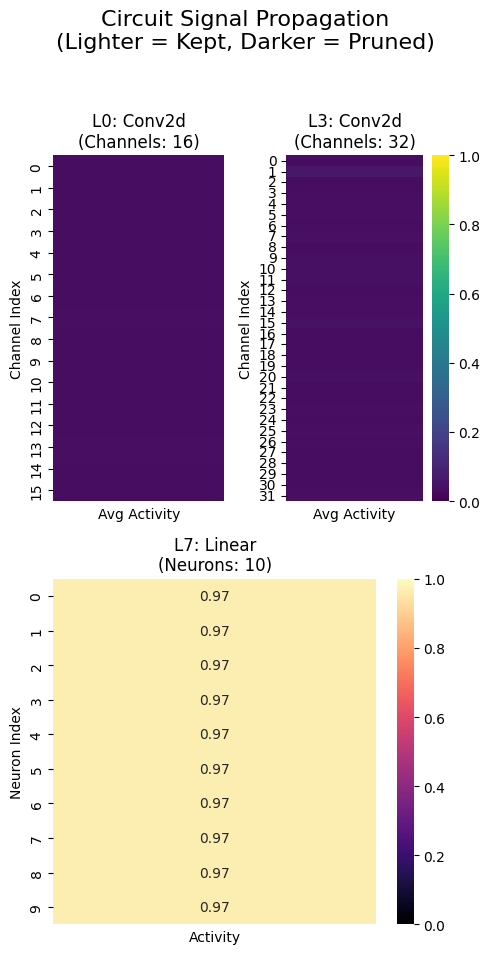


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png
Extracting duplicate 10/10 for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=800.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=800.0)...
Epoch 0 | Loss: 702.0181 | Avg Mask: -0.209 | Total Non-Zero: 3396.0 | | Circuit Acc: 0.1934
Epoch 1 | Loss: 1.7431 | Avg Mask: -0.995 | Total Non-Zero: 34.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 1.4104 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 1.1678 | Avg Mask: -0.997 | Total Non-Zero: 21.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 1.2846 | Avg Mask: -0.997 | Total Non-Zero: 14.0 | | Circuit Acc: 1.0000
Epoch 5 | Loss: 1.2601 | Avg Mask: -0.996 | Total Non-Zero: 11.0 | | Circuit Acc: 1.0000
Epoch 6 | Loss: 1.2625 | Avg Mask: -0.996 | Total Non-Zero: 17.0 | | Circuit Acc: 1.0000
Epoch 7 | Loss: 1.2414 | Avg Mask: -0.996 | Total Non-Zero: 16.0 | | Circuit Acc: 1.0000
Epoch 8 | Loss: 1.1633 | Avg Mask: -0.997 | Total Non-Zero: 22.0 | | Circuit Acc: 1.0000
Epoch 9 | Loss: 1.2358 | Avg Mask: -0.997 | Total Non-Zero: 20.0 | | Circ

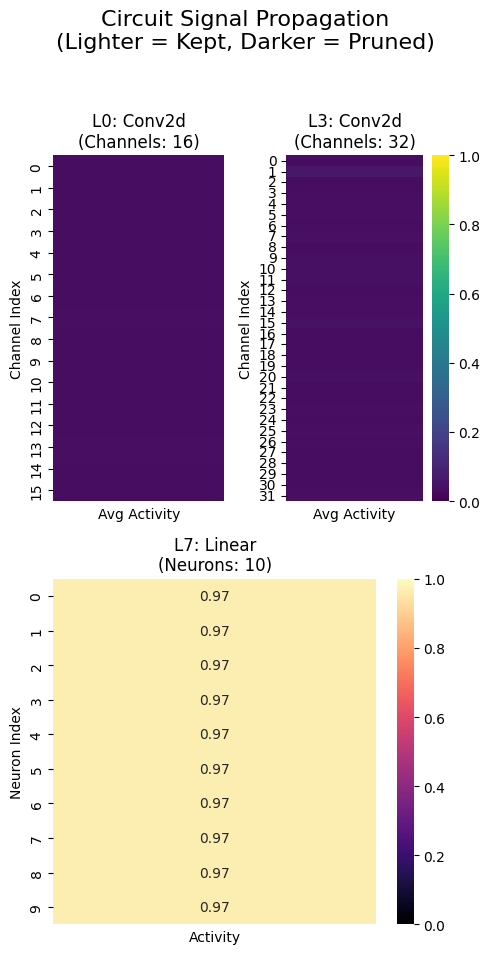


Visualization saved to circuit_visualization.png
Saved visualization to: circuit_viz_class_3.png


In [29]:
TARGET_REDUNDANCY_CLASS = 3

redundant_circuits = get_n_circuits_same_class(
    model=model,
    class_idx=TARGET_REDUNDANCY_CLASS,
    epochs=10
)

redundant_circuits = {f"Run_{i}": c for i, c in enumerate(redundant_circuits)}

In [30]:
red_accs = []
for idx, c in enumerate(redundant_circuits.values()):
    accs = class_wise_acc(c, testloader, classes=[TARGET_REDUNDANCY_CLASS], device=device)
    red_accs.append(accs[TARGET_REDUNDANCY_CLASS])
    print(f"Circuit {idx+1} Accuracy (Class {TARGET_REDUNDANCY_CLASS}): {accs[TARGET_REDUNDANCY_CLASS]:.2%}")

Circuit 1 Accuracy (Class 3): 100.00%
Circuit 2 Accuracy (Class 3): 100.00%
Circuit 3 Accuracy (Class 3): 100.00%
Circuit 4 Accuracy (Class 3): 100.00%
Circuit 5 Accuracy (Class 3): 100.00%
Circuit 6 Accuracy (Class 3): 100.00%
Circuit 7 Accuracy (Class 3): 100.00%
Circuit 8 Accuracy (Class 3): 100.00%
Circuit 9 Accuracy (Class 3): 100.00%
Circuit 10 Accuracy (Class 3): 100.00%


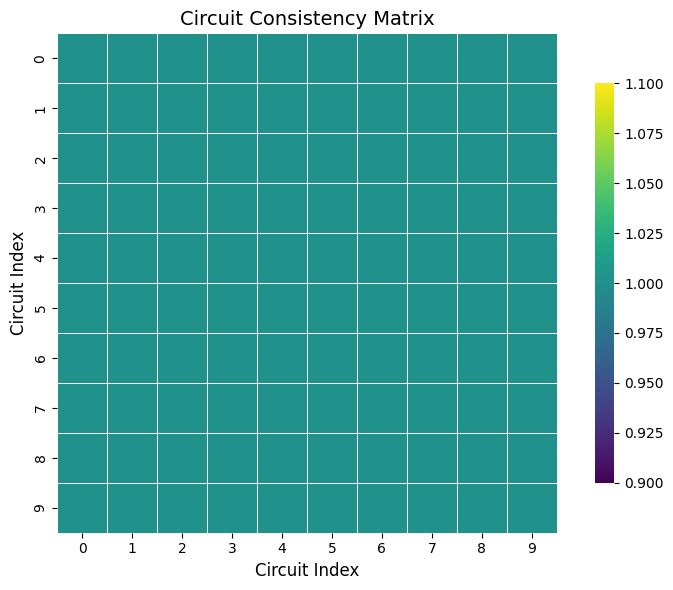

In [34]:
consistency_matrix = circuit_consistency_matrix(list(redundant_circuits.values()), len(redundant_circuits))

visualize_consistency_matrix(consistency_matrix)

In [39]:
red_union = union_circuits(list(redundant_circuits.values()))

union_iso_res = isolation_testing(red_union, trainloader)

union_nec_res = necessity_testing(red_union, trainloader)

In [40]:
print(union_iso_res)

{0: 0.04592267432044572, 1: 0.0, 2: 0.0, 3: 0.9709672157886152, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0}


In [41]:
print(union_nec_res)

{0: 0.988856998142833, 1: 0.99110056363097, 2: 0.8648875461564284, 3: 0.9752079595498288, 4: 0.96901745977405, 5: 0.9090573694890242, 6: 0.9775261912808382, 7: 0.9707901037509976, 8: 0.7191933002905486, 9: 0.8974617582787023}


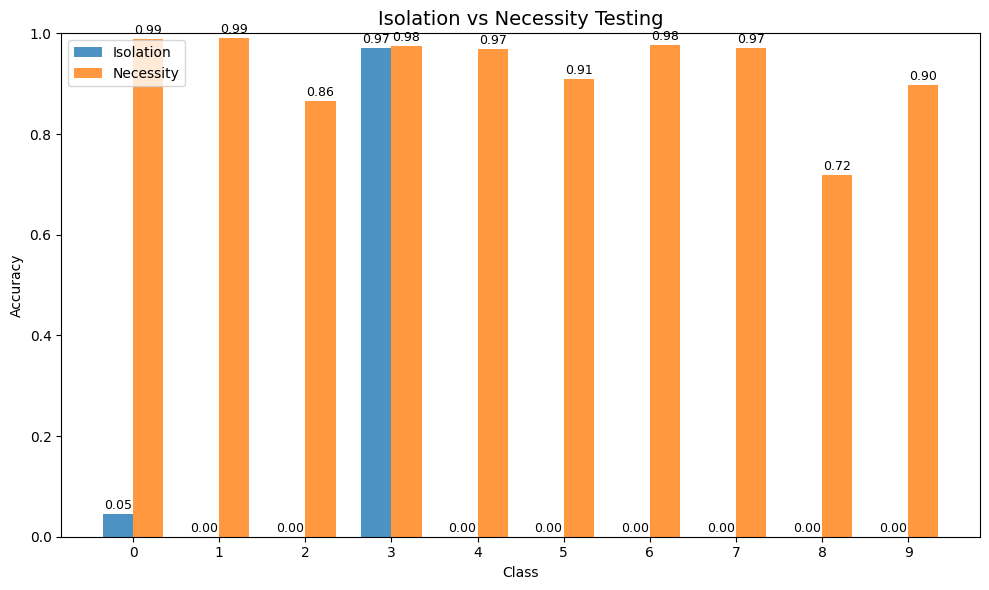

In [ ]:
visualize_iso_nec(union_iso_res, union_nec_res)

In [ ]:
red_divergence_results = path_divergence_dict(
    circuits_dict=redundant_circuits,
    loader=testloader,
    device=device
)

plot_path_divergence_trajectories(red_divergence_results, "out/red_path_div.png", "Redundant Circuits Path Divergence")

Alpha 0.0: Acc Class 3 = 100.00%
Alpha 0.1: Acc Class 3 = 100.00%
Alpha 0.2: Acc Class 3 = 100.00%
Alpha 0.3: Acc Class 3 = 100.00%
Alpha 0.4: Acc Class 3 = 100.00%
Alpha 0.6: Acc Class 3 = 100.00%
Alpha 0.7: Acc Class 3 = 100.00%
Alpha 0.8: Acc Class 3 = 100.00%
Alpha 0.9: Acc Class 3 = 100.00%
Alpha 1.0: Acc Class 3 = 100.00%


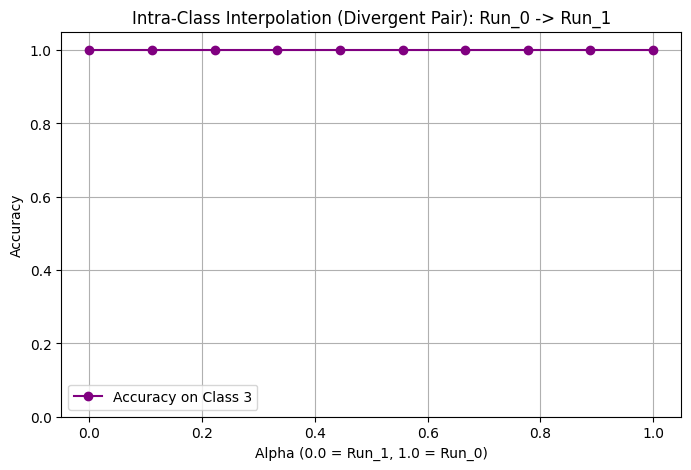

Alpha 0.0: Acc Class 3 = 100.00%
Alpha 0.1: Acc Class 3 = 100.00%
Alpha 0.2: Acc Class 3 = 100.00%
Alpha 0.3: Acc Class 3 = 100.00%
Alpha 0.4: Acc Class 3 = 100.00%
Alpha 0.6: Acc Class 3 = 100.00%
Alpha 0.7: Acc Class 3 = 100.00%
Alpha 0.8: Acc Class 3 = 100.00%
Alpha 0.9: Acc Class 3 = 100.00%
Alpha 1.0: Acc Class 3 = 100.00%


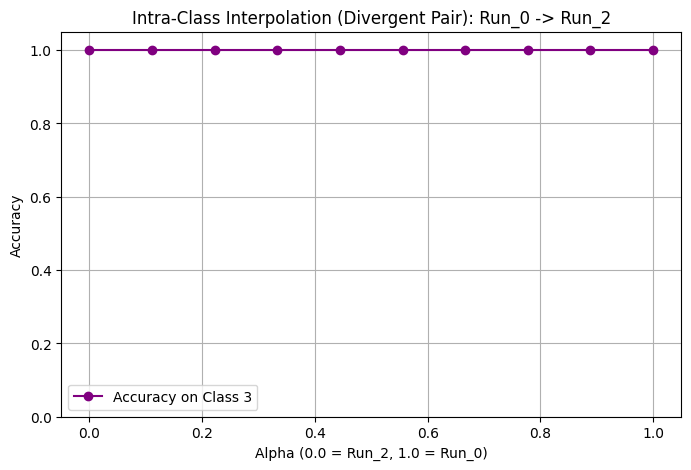

Alpha 0.0: Acc Class 3 = 100.00%
Alpha 0.1: Acc Class 3 = 100.00%
Alpha 0.2: Acc Class 3 = 100.00%
Alpha 0.3: Acc Class 3 = 100.00%
Alpha 0.4: Acc Class 3 = 100.00%
Alpha 0.6: Acc Class 3 = 100.00%
Alpha 0.7: Acc Class 3 = 100.00%
Alpha 0.8: Acc Class 3 = 100.00%
Alpha 0.9: Acc Class 3 = 100.00%
Alpha 1.0: Acc Class 3 = 100.00%


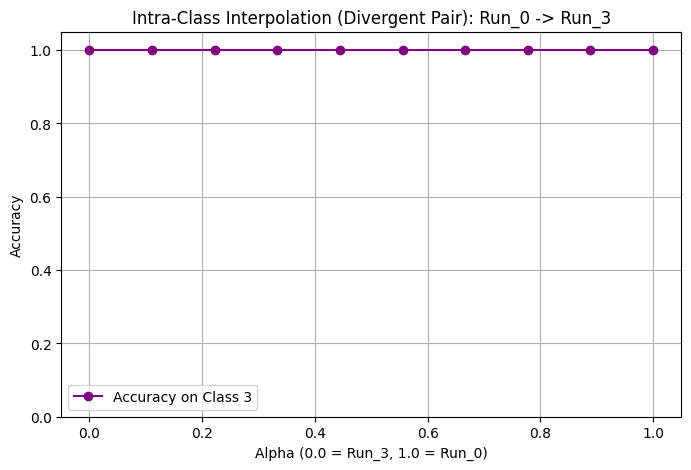

In [ ]:
sorted_red_pairs = sorted(red_divergence_results.items(), key=lambda x: x[1][-1])

red_div_interp = [pair[0] for pair in sorted_red_pairs[:3]]

for (run_a, run_b) in red_div_interp:
    # print(f"Interpolating between redundant circuits: {run_a} and {run_b}...")
    interp_circuits = get_interpolated_circuits(
        c_a=redundant_circuits[run_a], 
        c_b=redundant_circuits[run_b], 
        steps=10
    )
    
    alphas = list(interp_circuits.keys())
    acc_list = []
    
    for alpha, interp_c in interp_circuits.items():
        accs = class_wise_acc(interp_c, testloader, classes=[TARGET_REDUNDANCY_CLASS], device=device)
        acc_list.append(accs[TARGET_REDUNDANCY_CLASS])
        print(f"Alpha {alpha:.1f}: Acc Class {TARGET_REDUNDANCY_CLASS} = {accs[TARGET_REDUNDANCY_CLASS]:.2%}")
        
    plt.figure(figsize=(8, 5))
    plt.plot(alphas, acc_list, marker='o', label=f'Accuracy on Class {TARGET_REDUNDANCY_CLASS}', color='purple')
    plt.title(f"Intra-Class Interpolation (Divergent Pair): {run_a} -> {run_b}")
    plt.xlabel(f"Alpha (0.0 = {run_b}, 1.0 = {run_a})")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.savefig(f"out/red_interpolation_{run_a}_to_{run_b}.png")
    plt.show()
    plt.close()

### get n circuits same class n models

In [ ]:
N_MODELS = 3
TARGET_TEST_CLASS = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
model_config = {
    'lr': 1e-3, 'epochs': 15, 'ds_name': 'mnist-baseline', 
    'device': DEVICE, 'seed': 42, 'inp_shape': (1, 28, 28), 'num_classes': 10
}
sched = scheduler(start = 2, end= 10, start_sparsity=1, target_sparsity=0.10, alpha=0.15)

In [ ]:
mnist_models = train_n_models(N_MODELS, model_config)

In [ ]:
circuits = get_circuits_from_models(
    mnist_models, class_idx=TARGET_TEST_CLASS, epochs=3,
    lr=0.1,
    l0_lambda=5e+1
)

In [ ]:
circuits_dict = {f"Model_{i}": c for i, c in enumerate(circuits)}
mnist_train, mnist_test = train.load_dataset("mnist-baseline")

In [ ]:
plot_circuit_testing_heatmap(circuits_dict, isolation_testing, mnist_train, dev=DEVICE)

In [ ]:
plot_circuit_testing_heatmap(circuits_dict, necessity_testing, mnist_train, dev=DEVICE)

In [ ]:
cons_matrix = circuit_consistency_matrix(circuits, len(circuits))
visualize_consistency_matrix(cons_matrix, title=f"Consistency Matrix (Class {TARGET_TEST_CLASS})")

In [ ]:
div_dict = path_divergence_dict(circuits_dict, mnist_test, device=DEVICE)
plot_path_divergence_trajectories(div_dict, "out/n_models_path_div.png", f"Path Divergence (Class {TARGET_TEST_CLASS})")

In [ ]:
best_acc = -1
best_idx = 0

for i, c in enumerate(circuits):
    # Test on isolation accuracy for the target class
    accs = isolation_testing(c, mnist_test, classes=[TARGET_TEST_CLASS], dev=DEVICE)
    if accs[TARGET_TEST_CLASS] > best_acc:
        best_acc = accs[TARGET_TEST_CLASS]
        best_idx = i

best_mnist_model = mnist_models[best_idx]
best_mnist_circuit = circuits[best_idx]
print(f"Best Circuit is from Model_{best_idx} with Isolation Acc: {best_acc:.2%}")

### Cross Domain Testing

In [ ]:
color_config = model_config.copy()
color_config['ds_name'] = 'colour-mnist'

In [ ]:
colored_model = train_n_models(1, color_config)[0]

In [ ]:
color_train, color_test = train.load_dataset("colour-mnist")

In [ ]:
mnist_to_color_results = cross_model_circuit_test(
    src_model=best_mnist_model, 
    target_model=colored_model, 
    target_loader=color_test, 
    class_idx=TARGET_TEST_CLASS, 
    src_circuit=best_mnist_circuit, 
    dev=DEVICE
)

In [ ]:
color_to_mnist_results = cross_model_circuit_test(
    src_model=colored_model, 
    target_model=best_mnist_model, 
    target_loader=mnist_test, 
    class_idx=TARGET_TEST_CLASS, 
    src_circuit=None, # Will extract automatically
    dev=DEVICE
)